# 04 — Location Insights

Geographic distribution of IT jobs across German states and cities. Shows where hiring is concentrated, which cities dominate specific job families, and how remote work adoption varies by region.

In [1]:
from analysis.utils import notebook_init
from analysis.filters import exclude_future_dates, exclude_other_family

df_raw = notebook_init()
df = exclude_future_dates(df_raw)
print(f"After excluding future-dated rows: {len(df):,} rows")

Loaded 19,148 rows × 29 columns
After excluding future-dated rows: 19,098 rows


In [2]:
import pandas as pd
from analysis.charts import horizontal_bar, heatmap, stacked_bar
from analysis.compute import job_density_by_state, modality_by_state

## Data Quality & Coverage

In [3]:
city_known = df["city"].notna().sum()
state_known = df["state"].notna().sum()
modality_known = df["work_modality"].notna().sum()
total = len(df)

print(f"Total rows: {total:,}")
print(f"City available:     {city_known:,} / {total:,}  ({city_known/total*100:.1f}%)")
print(f"State available:    {state_known:,} / {total:,}  ({state_known/total*100:.1f}%)")
print(f"Modality available: {modality_known:,} / {total:,}  ({modality_known/total*100:.1f}%)")
print(f"Unique cities:  {df['city'].nunique():,}")
print(f"Unique states:  {df['state'].nunique():,}")

Total rows: 19,098
City available:     17,952 / 19,098  (94.0%)
State available:    18,063 / 19,098  (94.6%)
Modality available: 11,472 / 19,098  (60.1%)
Unique cities:  1,143
Unique states:  16


Most postings include geographic metadata, giving us strong coverage for location analysis.

## Jobs by State

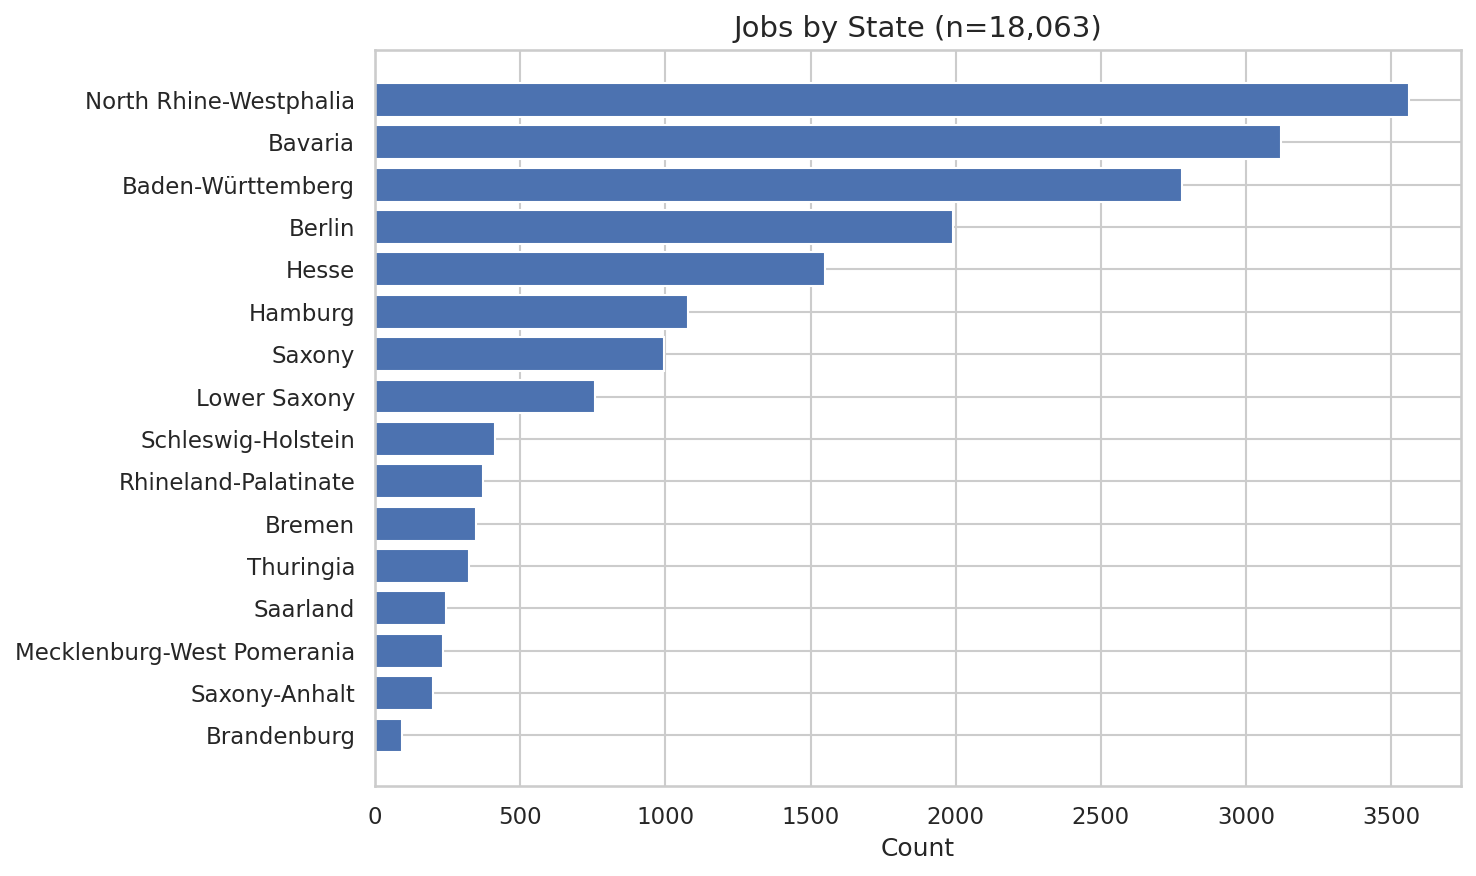

In [4]:
state_counts = job_density_by_state(df)
n_with_state = df["state"].notna().sum()

horizontal_bar(
    df[df["state"].notna()]["state"],
    f"Jobs by State (n={n_with_state:,})",
    save_as="04_state.png",
)

**Takeaway:** The German IT job market is heavily concentrated in a handful of states. Bavaria, North Rhine-Westphalia, and Baden-Württemberg together account for the majority of postings, reflecting the economic weight of Munich, the Rhine-Ruhr area, and Stuttgart. City-states like Berlin and Hamburg also punch above their geographic size.

## Top 20 Cities

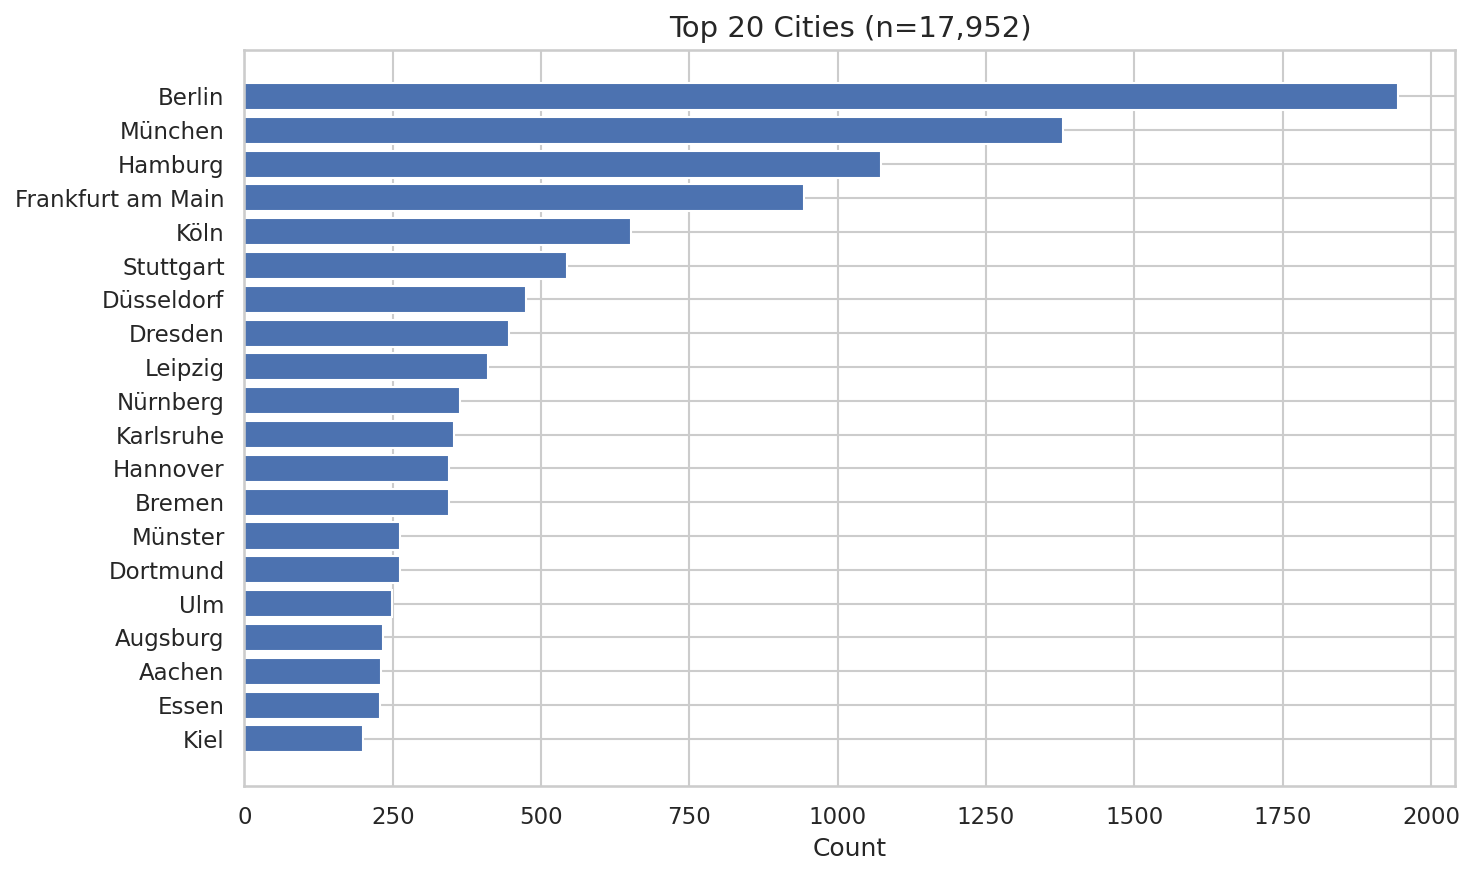

In [5]:
n_with_city = df["city"].notna().sum()

horizontal_bar(
    df[df["city"].notna()]["city"],
    f"Top 20 Cities (n={n_with_city:,})",
    top_n=20,
    save_as="04_cities.png",
)

**Takeaway:** Berlin leads by a significant margin, followed by Munich, Hamburg, and Frankfurt. These four cities form the core of the German IT hiring market. Mid-sized tech hubs such as Stuttgart, Düsseldorf, and Cologne also feature prominently, showing that opportunities extend well beyond the capital.

## City × Job Family Heatmap

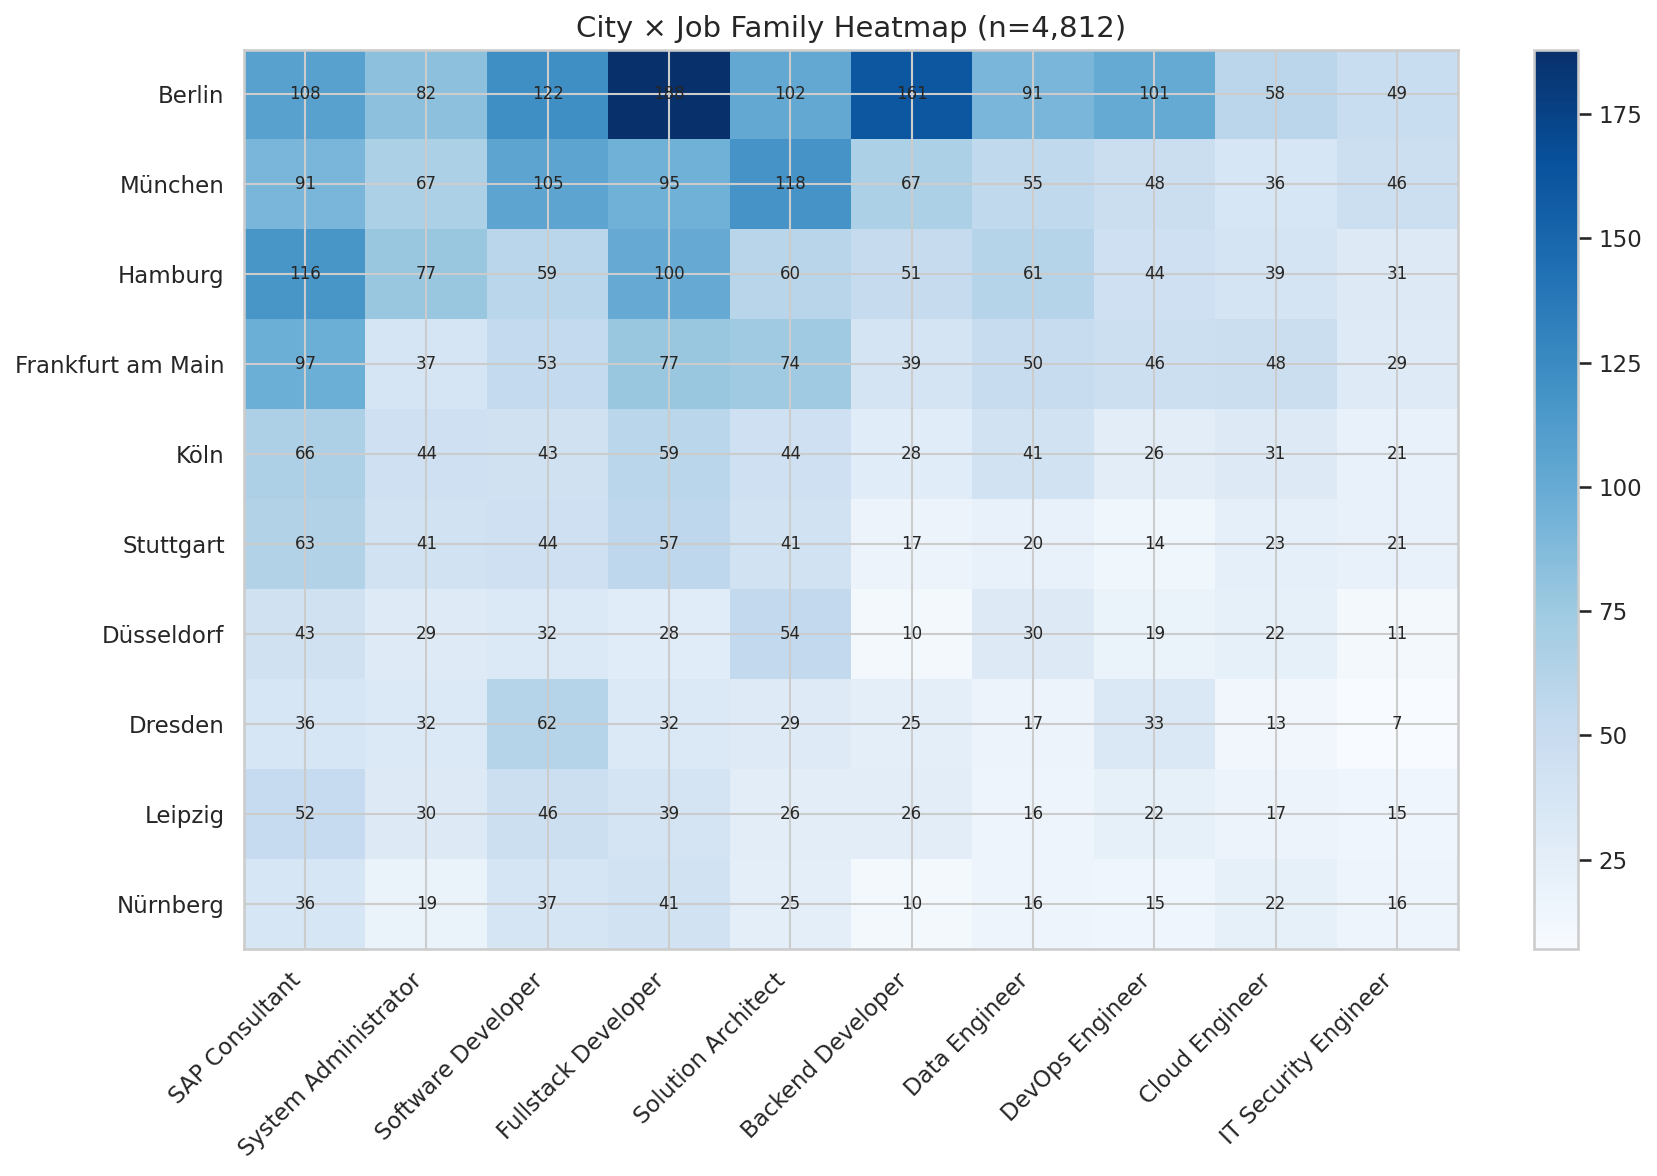

In [6]:
df_fam = exclude_other_family(df)
top_cities = df[df["city"].notna()]["city"].value_counts().head(10).index
top_families = df_fam["job_family"].value_counts().head(10).index

pivot = (
    df_fam[df_fam["city"].isin(top_cities) & df_fam["job_family"].isin(top_families)]
    .groupby(["city", "job_family"])
    .size()
    .unstack(fill_value=0)
)
pivot = pivot.reindex(index=top_cities, columns=top_families, fill_value=0)

n_heatmap = len(df_fam[df_fam["city"].isin(top_cities) & df_fam["job_family"].isin(top_families)])
heatmap(pivot, f"City × Job Family Heatmap (n={n_heatmap:,})", save_as="04_city_family.png")

**Takeaway:** Berlin dominates nearly every job family, but specialisation patterns emerge: Munich is relatively stronger in data-related roles, while Frankfurt sees a higher share of consulting and SAP positions. Smaller cities tend to concentrate in one or two families rather than spreading evenly across all disciplines.

## Remote vs On-site by State

Sample sizes per state:
  North Rhine-Westphalia: n=3,562
  Bavaria: n=3,120
  Baden-Württemberg: n=2,780
  Berlin: n=1,992
  Hesse: n=1,550
  Hamburg: n=1,079
  Saxony: n=994
  Lower Saxony: n=757
  Schleswig-Holstein: n=414
  Rhineland-Palatinate: n=371


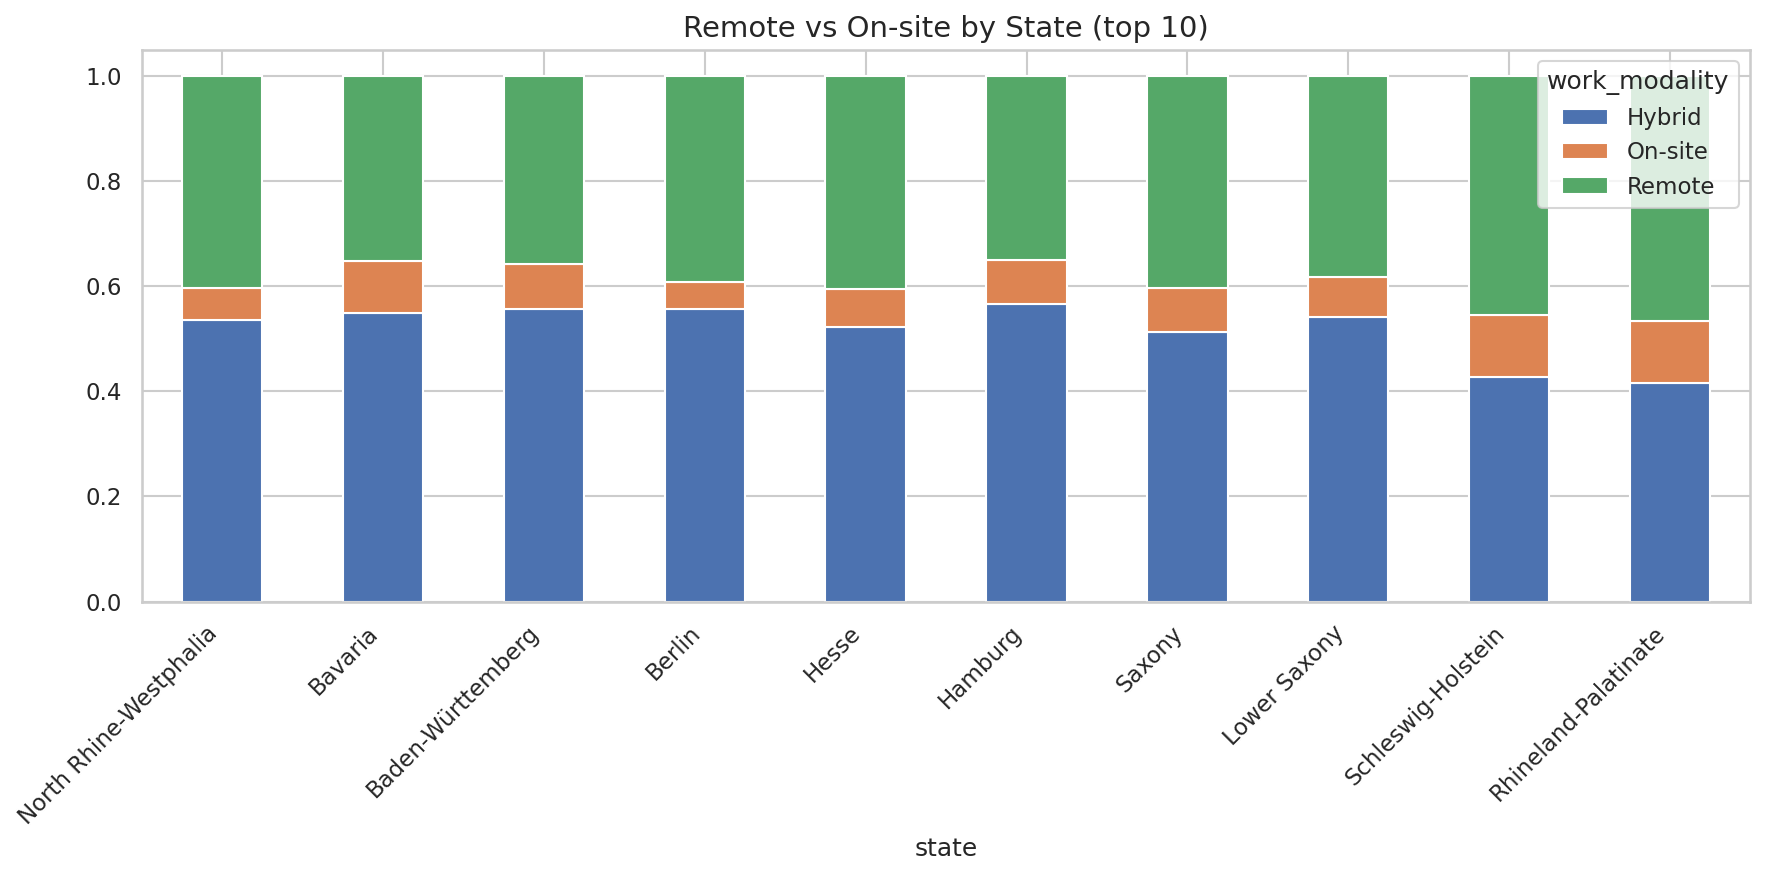

In [7]:
# Use compute helper for modality breakdown by state
modality_pct = modality_by_state(df, top_n_states=10)

# Convert from percentage back to proportion for stacked_bar (which expects 0-1 range)
modality_prop = modality_pct / 100

# Print sample sizes per state
top_states = df["state"].value_counts().head(10).index
state_n = df[df["state"].isin(top_states)].groupby("state").size()
print("Sample sizes per state:")
for s in top_states:
    print(f"  {s}: n={state_n.get(s, 0):,}")

stacked_bar(modality_prop, "Remote vs On-site by State (top 10)", save_as="04_remote_state.png")

**Takeaway:** Remote and hybrid work adoption varies meaningfully by state. City-states like Berlin tend to have higher remote shares, likely driven by the prevalence of startups and digital-native companies. More industrial states show a stronger on-site preference, reflecting the nature of their IT roles (e.g., embedded systems, manufacturing IT).